In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

### Imports

In [2]:
import os
import random
import glob
import warnings
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchaudio

import librosa
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 23456543
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


### Config

In [3]:
DATA_ROOT = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup"
OUTPUT_DIR = "./outputs"

STEMS_DIR = os.path.join(DATA_ROOT, "genres_stems")
NOISE_DIR = os.path.join(DATA_ROOT, "ESC-50-master", "audio")
TEST_DIR = os.path.join(DATA_ROOT, "mashups")
TEST_CSV = os.path.join(DATA_ROOT, "test.csv")

# audio params
SR = 22050 # Sampling Rate
DURATION = 10.0 # 10s
TARGET_LEN = int(SR * DURATION) # 220500 samples
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FMIN = 20
FMAX = 8000

GENRES = sorted(['blues', 'classical', 'country', 'disco', 'hiphop',
                 'jazz', 'metal', 'pop', 'reggae', 'rock'])


GENRES2IDX = {g : i for i, g in enumerate(GENRES)}
IDX2GENRES = {i : g for g, i in GENRES2IDX.items()}
STEMS = ["drums", "vocals", "bass", "other"]

SAMPLES_PER_GENRE = 1000 # 10k mashups per epoch
BATCH_SIZE = 32
EPOCHS = 35
LR = 1e-3
WEIGHT_DECAY = 1e-4 # l2-reg
LABEL_SMOOTHING = 0.1 # better generalization
NUM_WORKERS = 4
MIXUP_ALPHA = 0.4

# from EDA
STEM_WEIGHTS = {
    "drums": 0.45,
    "vocals": 0.30,
    "bass": 0.15,
    "other": 0.10
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Will train on {SAMPLES_PER_GENRE * 10} mashups per epoch")

Will train on 10000 mashups per epoch


### Data Index and Split

Go through all folders and find which stems are available for each song. \
Then split into train (85%) and val (15%)

In [4]:
stem_index = {g : {st: [] for st in STEMS} for g in GENRES}
song_index = {g : [] for g in GENRES}

for genre in GENRES:
    genre_path = os.path.join(STEMS_DIR, genre)
    songs = sorted(s for s in os.listdir(genre_path)
                    if os.path.isdir(os.path.join(genre_path, s)))

    for song in songs:
        song_dir = os.path.join(genre_path, song)
        available_stems = []
        for stem in STEMS:
            filepath = os.path.join(song_dir, f"{stem}.wav")
            if os.path.exists(filepath):
                stem_index[genre][stem].append(filepath)
                available_stems.append(stem)

        if available_stems:
            song_index[genre].append({
                'dir': song_dir,
                "stems": available_stems
            })


noise_files = sorted(glob.glob(os.path.join(NOISE_DIR, "*.wav")))
print(f"Found {len(noise_files)} noise clips from ESC-50")

Found 2000 noise clips from ESC-50


In [5]:
train_stems = {g : {st: [] for st in STEMS} for g in GENRES}
val_songs = {g: [] for g in GENRES}

for genre in GENRES:
    songs = song_index[genre].copy()
    random.shuffle(songs)
    split_point = int(0.85 * len(songs))

    # slice
    train_list = songs[:split_point]
    val_list = songs[split_point:]
    val_songs[genre] = val_list

    # only use stems from training songs
    train_dirs = {s['dir'] for s in train_list}
    for stem in STEMS:
        train_stems[genre][stem] = [
            fp for fp in stem_index[genre][stem]
            if os.path.dirname(fp) in train_dirs
        ]

    print(f"   {genre}: {len(train_list)} train, {len(val_list)} val")

   blues: 85 train, 15 val
   classical: 85 train, 15 val
   country: 85 train, 15 val
   disco: 85 train, 15 val
   hiphop: 85 train, 15 val
   jazz: 85 train, 15 val
   metal: 85 train, 15 val
   pop: 85 train, 15 val
   reggae: 85 train, 15 val
   rock: 85 train, 15 val


### Helper Functions

Loading and converting to Mel-Spectrograms

In [6]:
CACHE_DIR = "./wav_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def cache_path(orig_path):
    # flatten path into a safe filename
    key = orig_path.replace("/", "_")
    return os.path.join(CACHE_DIR, key + ".npy")

def precompute_cache(filepaths):
    for fp in tqdm(filepaths, desc="Caching waveforms"):
        cp = cache_path(fp)
        if os.path.exists(cp):
            continue
        try:
            y, _ = librosa.load(fp, sr=SR, mono=True)
        except Exception:
            y = np.zeros(TARGET_LEN, dtype=np.float32)
        np.save(cp, y.astype(np.float32))

# gather every file that will ever be loaded
all_files = set()
for genre in GENRES:
    for stem in STEMS:
        all_files.update(stem_index[genre][stem])
all_files.update(noise_files)

precompute_cache(list(all_files))

def load_wav(path, sr=SR, target_len=TARGET_LEN):
    cp = cache_path(path)
    try:
        y = np.load(cp)
    except Exception:
        y = np.zeros(target_len, dtype=np.float32)
    # clip or pad happens per-call since crop is random each time
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        start = random.randint(0, len(y) - target_len)
        y = y[start:start + target_len]
    return y.astype(np.float32)

# def load_wav(path, sr=SR, target_len=TARGET_LEN):
#     try:
#         y, _ = librosa.load(path, sr=sr, mono=True)

#         # clip or pad
#         if len(y) < target_len:
#             y = np.pad(y, (0, target_len - len(y)))
#         elif len(y) > target_len:
#             start = random.randint(0, len(y) - target_len)
#             y = y[start : start + target_len]

#         return y.astype(np.float32)

#     except:
#         return np.zeros(target_len, dtype=np.float32)


def wav_to_mel(y, sr=SR):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX
    )
    
    S_db = librosa.power_to_db(S, ref=np.max, top_db=80)
    return S_db.astype(np.float32)

Caching waveforms:   0%|          | 0/6000 [00:00<?, ?it/s]

In [7]:
def load_wav_tta(path, sr=SR, target_len=TARGET_LEN):
    cp = cache_path(path)
    try:
        y = np.load(cp)
    except Exception:
        try:
            y, _ = librosa.load(path, sr=sr, mono=True)
        except Exception:
            y = np.zeros(target_len, dtype=np.float32)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        start = random.randint(0, len(y) - target_len)  # random, not center — this is what makes TTA rounds differ
        y = y[start:start + target_len]
    return y.astype(np.float32)

SpecAugment
- Mask random frequency bands and time steps in the spectrogram to make the model more robust

In [8]:
def spec_augment(spec, freq_mask=27, time_mask=80, n_freq=2, n_time=2):
    _, _, n_mels, n_frames = spec.shape
    aug = spec.clone()

    # mask freq
    for _ in range(n_freq):
        f = random.randint(0, freq_mask)
        f0 = random.randint(0, max(0, n_mels - f))
        aug[:, :, f0: f0+f, :] = 0

    # mask time
    for _ in range(n_time):
        t = random.randint(0, time_mask)
        t0 = random.randint(0, max(0, n_frames - t))
        aug[:, :, :, t0:t0+t] = 0

    return aug

### Dataset

In [9]:
class MashupDataset(Dataset):
    def __init__(self, stem_idx, noise_files, samples_per_genre=1000, augment=True):
        self.stem_idx = stem_idx
        self.noise_files = noise_files
        self.augment = augment
        self.samples = []
        for genre in GENRES:
            for _ in range(samples_per_genre):
                self.samples.append(GENRES2IDX[genre])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre_idx = self.samples[idx]
        genre = IDX2GENRES[genre_idx]

        # stem mixing
        stems_wav = []
        for stem_type in STEMS:
            available = self.stem_idx[genre][stem_type]
            if not available:
                continue
            wav = load_wav(random.choice(available))
            # weight stems by importance
            gain = random.uniform(0.5, 1.5) * (STEM_WEIGHTS[stem_type] / 0.25)
            stems_wav.append(wav * gain)

        if not stems_wav:
            mel = np.zeros((N_MELS, TARGET_LEN // HOP_LENGTH + 1), dtype=np.float32)
            return torch.from_numpy(mel).unsqueeze(0), genre_idx

        # mix all up
        mix = np.sum(stems_wav, axis=0)

        if self.augment:
            mix = np.roll(mix, random.randint(-SR, SR))

            # add ESC noise (0-2 at random SNR)
            for _ in range(random.randint(0, 2)):
                noise = load_wav(random.choice(self.noise_files))
                snr_db = random.uniform(5.0, 25.0)
                sig_pwr = np.mean(mix ** 2) + 1e-10
                nse_pwr = np.mean(noise ** 2) + 1e-10
                scale = np.sqrt(sig_pwr / (nse_pwr * 10 ** (snr_db / 10)))
                mix = mix + noise * scale

            if random.random() < 0.3:
                mix = np.clip(mix * random.uniform(1.2, 3.0), -1, 1)

        # normalise
        peak = np.max(np.abs(mix))
        if peak > 1e-6:
            mix = mix / peak * random.uniform(0.7, 1.0)

        # mel = wav_to_mel(mix)
        # return torch.from_numpy(mel).unsqueeze(0), genre_idx
        return torch.from_numpy(mix).float(), genre_idx

In [10]:
class ValDataset(Dataset):
    def __init__(self, song_idx):
        self.items = []
        for genre in GENRES:
            for song in song_idx[genre]:
                self.items.append((song, GENRES2IDX[genre]))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        song_info, label = self.items[idx]
        stems = [load_wav(os.path.join(song_info['dir'], f"{st}.wav")) for st in song_info['stems']]
        mix = np.sum(stems, axis=0)
        peak = np.max(np.abs(mix))
        if peak > 1e-6:
            mix = mix / peak
        # mel = wav_to_mel(mix)
        # return torch.from_numpy(mel).unsqueeze(0), label
        return torch.from_numpy(mix).float(), label


class TestDataset(Dataset):
    def __init__(self, test_dir, test_csv):
        self.df = pd.read_csv(test_csv, dtype={'id': str})
        self.paths = []
        for _, row in self.df.iterrows():
            path = None
            for pattern in [f"song{str(row['id']).zfill(4)}.wav",
                            f"{row['id']}.wav",
                            f"song{row['id']}.wav"
                           ]:
                p = os.path.join(test_dir, pattern)
                if os.path.exists(p):
                    path = p
                    break
            self.paths.append(path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.paths[idx]
        if path:
            # mel = wav_to_mel(load_wav(path))
            # mel_tensor = torch.from_numpy(mel).unsqueeze(0)
            wav = load_wav_tta(path)
            peak = np.max(np.abs(wav))
            if peak > 1e-6:
                wav = wav / peak
            wav_tensor = torch.from_numpy(wav).float()
        else:
            wav_tensor = torch.zeros(TARGET_LEN, dtype=torch.float32)
        return wav_tensor, str(self.df.iloc[idx]['id'])


### Model

**EfficientNet-B0** pretrained on ImageNet, adapted for single channel mel-spectrograms.

Key components:
- Instance Norm: makes the model volume-invariant (Classical is 20x quieter than hiphop)
- GeM Pooling: focuses on high-activation regions instead of averaging everything
- SpecAugment: applied during training for regularization

In [11]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=(-2, -1)).pow(1.0 / self.p)

class GenreClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.inst_norm = nn.InstanceNorm2d(1) # volume norm
        self.backbone = timm.create_model(
            "efficientnet_b0", pretrained=True,
            in_chans=1, num_classes=0, global_pool=''
        )
        num_features = self.backbone.num_features # 1280 for effnet-b0
        self.gem = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x, augment=False):
        x = self.inst_norm(x)
        if augment:
            x = spec_augment(x)
        features = self.backbone(x)
        pooled = self.gem(features)
        return self.head(pooled)

# sanity check
model = GenreClassifier().to(DEVICE)
dummy = torch.randn(2, 1, N_MELS, TARGET_LEN // HOP_LENGTH + 1).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
del dummy, out
gc.collect()
torch.cuda.empty_cache()   

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Output shape: torch.Size([2, 10])
Parameters: 4.0M


### Mixup Augmentation

Mixup blends two training samples and their labels. \
Its like stacking melspectrograms -- Classical + Blues

In [12]:
def mixup_data(x, y, alpha=0.4):
    # Mix two samples with random weight from Beta distribution
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    # Weighted loss for mixed labels
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### Training and Eval

In [13]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=FMIN, f_max=FMAX
).to(DEVICE)
db_transform = torchaudio.transforms.AmplitudeToDB(top_db=80).to(DEVICE)

def wav_batch_to_mel(wav_batch):
    # wav_batch: (B, T) on DEVICE
    mel = mel_transform(wav_batch)          # (B, n_mels, frames)
    mel_db = db_transform(mel)
    return mel_db.unsqueeze(1)              # (B, 1, n_mels, frames)

In [14]:
def train_one_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss = 0
    num_samples = 0

    for wav, labels in tqdm(loader, desc="Train", leave=False):
        wav = wav.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()

        # mel/db in fp32 — avoids amin=1e-10 underflowing under fp16
        mel = wav_batch_to_mel(wav)
        assert torch.isfinite(mel).all(), "non-finite values in mel"
        
        with autocast():
            # apply mixup 50% of the time
            if random.random() < 0.5:
                mel_mixed, y_a, y_b, lam = mixup_data(mel, labels, MIXUP_ALPHA)
                logits = model(mel_mixed, augment=True)
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                logits = model(mel, augment=True)
                loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(labels)
        num_samples += len(labels)

    return total_loss / num_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for wav, labels in loader:
        wav = wav.to(DEVICE)
        mel = wav_batch_to_mel(wav)

        with autocast():
            logits = model(mel, augment=False)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

    f1 = f1_score(all_labels, all_preds, average="macro")
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return f1, acc, np.array(all_preds), np.array(all_labels)

In [19]:
train_dataset = MashupDataset(train_stems, noise_files, SAMPLES_PER_GENRE, augment=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=4,
)

val_dataset = ValDataset(val_songs)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Validation samples: {len(val_dataset)}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scaler = GradScaler()

best_f1 = 0.0
history = {
    "loss": [],
    "val_f1": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    loss = train_one_epoch(model, train_loader, optimizer, scaler, criterion)
    scheduler.step()

    val_f1, val_acc, _, _ = evaluate(model, val_loader)
    lr = scheduler.get_last_lr()[0]
    elapsed = time.time() - start_time

    # track history
    history['loss'].append(loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    history['lr'].append(lr)

    # save best model
    tag = ""
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_cnn.pth'))
        tag = " [best]"

    print(f"E{epoch:02d}/{EPOCHS} | loss={loss:.4f} | f1={val_f1:.4f} | "
          f"acc={val_acc:.4f} | lr={lr:.6f} | {elapsed:.0f}s{tag}")

print(f"\nBest validation F1: {best_f1:.4f}")

Validation samples: 150


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E01/35 | loss=1.5774 | f1=0.6993 | acc=0.7200 | lr=0.000998 | 114s [best]


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E02/35 | loss=1.2528 | f1=0.7863 | acc=0.7867 | lr=0.000992 | 44s [best]


...

E33/35 | loss=0.7317 | f1=0.8665 | acc=0.8667 | lr=0.000009 | 45s


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E34/35 | loss=0.7278 | f1=0.8667 | acc=0.8667 | lr=0.000003 | 44s


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E35/35 | loss=0.7587 | f1=0.8719 | acc=0.8733 | lr=0.000001 | 44s

Best validation F1: 0.8863


### Plots

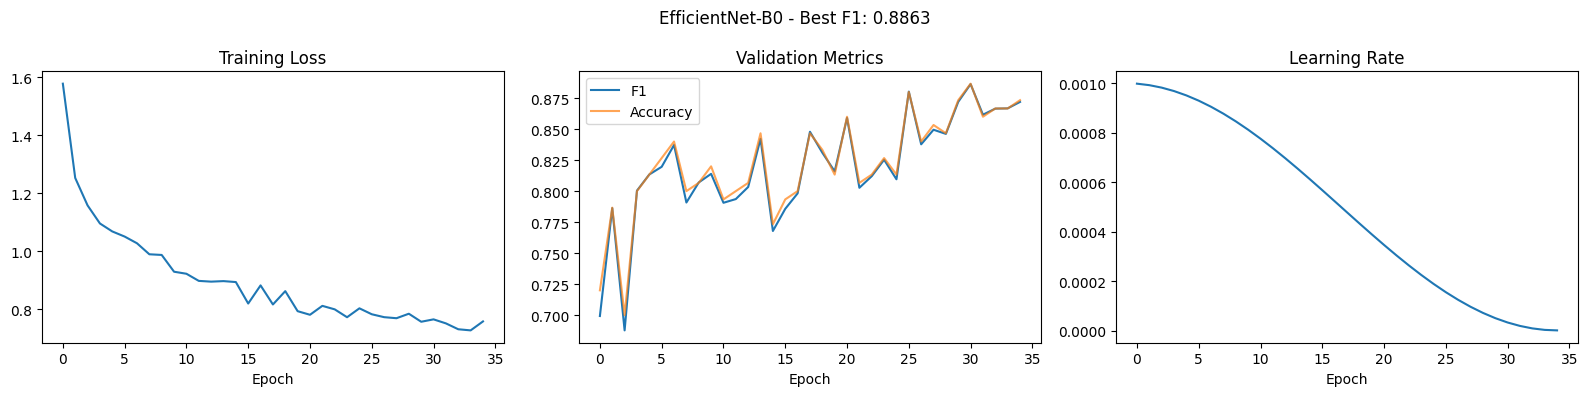

In [21]:
# training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_f1'], label='F1')
axes[1].plot(history['val_acc'], label='Accuracy', alpha=0.7)
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')

plt.suptitle(f'EfficientNet-B0 - Best F1: {best_f1:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

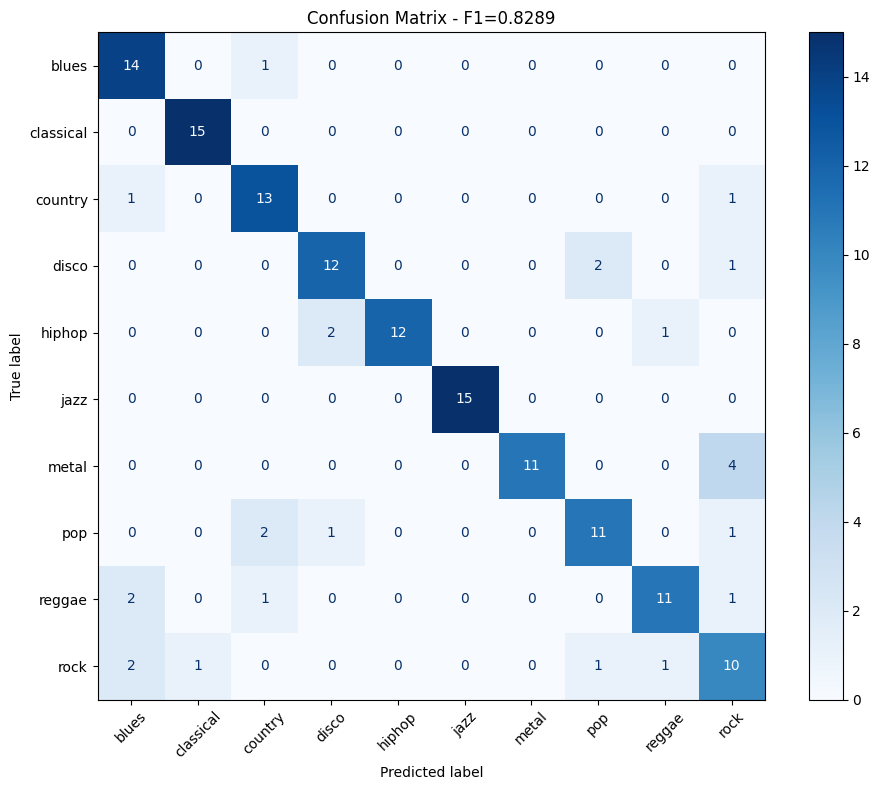

              precision    recall  f1-score   support

       blues       0.74      0.93      0.82        15
   classical       0.94      1.00      0.97        15
     country       0.76      0.87      0.81        15
       disco       0.80      0.80      0.80        15
      hiphop       1.00      0.80      0.89        15
        jazz       1.00      1.00      1.00        15
       metal       1.00      0.73      0.85        15
         pop       0.79      0.73      0.76        15
      reggae       0.85      0.73      0.79        15
        rock       0.56      0.67      0.61        15

    accuracy                           0.83       150
   macro avg       0.84      0.83      0.83       150
weighted avg       0.84      0.83      0.83       150



In [23]:
# confusion matrix on best model
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_cnn.pth'), weights_only=True))
val_f1, val_acc, preds, labels = evaluate(model, val_loader)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=GENRES).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix - F1={val_f1:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(classification_report(labels, preds, target_names=GENRES))

### Inference - TTA

In [15]:
model = GenreClassifier(num_classes=10).to(DEVICE)
model.load_state_dict(torch.load(os.path.join("/kaggle/input/models/kaushalvaid/efficientnet-b0-messy-audiogenre-classification/pytorch/default/1/best_efficientnet-b0.pth"), map_location=DEVICE))
model.eval()

test_ds = TestDataset(TEST_DIR, TEST_CSV)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test samples: {len(test_ds)}")
print(sum(p is None for p in test_ds.paths))

Test samples: 3020
0


In [16]:
@torch.no_grad()
def predict_tta(model, loader, n_tta=5):
    model.eval()
    all_ids = None
    all_probs = []
    for t in range(n_tta):
        round_probs, ids_this_round = [], []
        for wav, ids in loader:
            wav = wav.to(DEVICE)
            mel = wav_batch_to_mel(wav)
            with autocast():
                logits = model(mel, augment=False)
            round_probs.append(F.softmax(logits, dim=1).float().cpu().numpy())
            ids_this_round.extend(ids)
        all_probs.append(np.vstack(round_probs))
        if all_ids is None:
            all_ids = ids_this_round  # order is stable since shuffle=False
    avg_probs = np.mean(all_probs, axis=0)
    return avg_probs.argmax(1), all_ids, avg_probs

preds, ids, probs = predict_tta(model, test_loader, n_tta=5)
print(f"Prediction distribution: {Counter(preds)}")

Prediction distribution: Counter({np.int64(9): 330, np.int64(0): 320, np.int64(5): 309, np.int64(6): 308, np.int64(4): 308, np.int64(8): 308, np.int64(3): 301, np.int64(7): 283, np.int64(2): 281, np.int64(1): 272})


### Submission

In [17]:
test_df = pd.read_csv(TEST_CSV, dtype={'id': str})
pred_dict = {str(id_): IDX2GENRES[p] for id_, p in zip(ids, preds)}
test_df['genre'] = test_df['id'].apply(lambda x: pred_dict.get(str(x), 'rock'))
test_df[['id', 'genre']].to_csv(os.path.join(OUTPUT_DIR, 'submission.csv'), index=False)
print("Submission saved!")
print(test_df['genre'].value_counts().sort_index())

np.save(os.path.join(OUTPUT_DIR, 'test_probs_efficientnet.npy'), probs)

Submission saved!
genre
blues        320
classical    272
country      281
disco        301
hiphop       308
jazz         309
metal        308
pop          283
reggae       308
rock         330
Name: count, dtype: int64
